In [1]:
import pandas as pd
df = pd.read_csv('car_uk_brands.csv')
display(df.head())

,brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Audi,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,Audi,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,Audi,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,Audi,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,Audi,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [2]:
print("Data Missed in Each Column:")
print(df.isnull().sum())
print("-" * 50)
print("Num Of Duplicated Rows:", df.duplicated().sum())
print("-" * 50)
df.info()

Data Missed in Each Column:
brand           0
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
--------------------------------------------------
Num Of Duplicated Rows: 1475
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         99187 non-null  str    
 1   model         99187 non-null  str    
 2   year          99187 non-null  int64  
 3   price         99187 non-null  int64  
 4   transmission  99187 non-null  str    
 5   mileage       99187 non-null  int64  
 6   fuelType      99187 non-null  str    
 7   tax           99187 non-null  int64  
 8   mpg           99187 non-null  float64
 9   engineSize    99187 non-null  float64
dtypes: float64(2), int64(4), str(

In [2]:
df = df.drop_duplicates()
print("Num Of Duplicated Rows After Removing Duplicates:", df.duplicated().sum())
print("-" * 50)
display(df.describe())

Num Of Duplicated Rows After Removing Duplicates: 0
--------------------------------------------------


,year,price,mileage,tax,mpg,engineSize
count,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000
mean,2017.066870,16773.487555,23219.475499,120.142408,55.205623,1.664913
std,2.122993,9868.552222,21060.882301,63.357250,16.181659,0.558574
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000
50%,2017.000000,14470.000000,17682.500000,145.000000,54.300000,1.600000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000
max,2060.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


- --> year of make -->> 2060 in max   This is outlier
- --> Engine size in min this is = 0.0 .... this is impossible
- --> mpg max is equal 470.8 this is impossible in عربيات البنزين

In [3]:
df = df[df['year'] <= 2026]
df = df[df['engineSize'] > 0]
df = df[df['mpg'] <= 200]

In [5]:
print("Num Of Rows After Removing Outliers:", len(df))

Num Of Rows After Removing Outliers: 97397


### EDA

Matplotlib is building the font cache; this may take a moment.


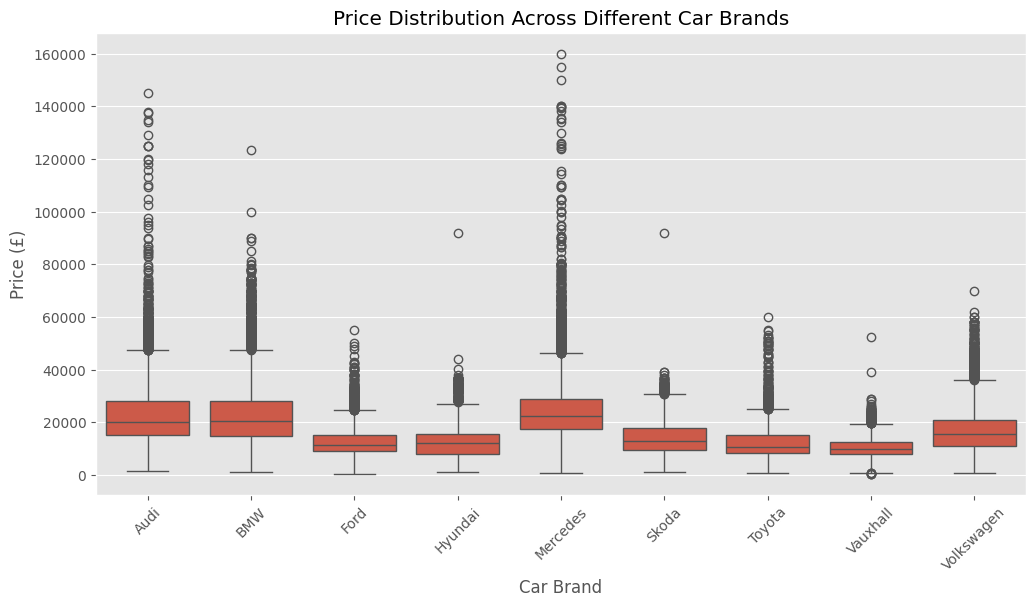

--------------------------------------------------


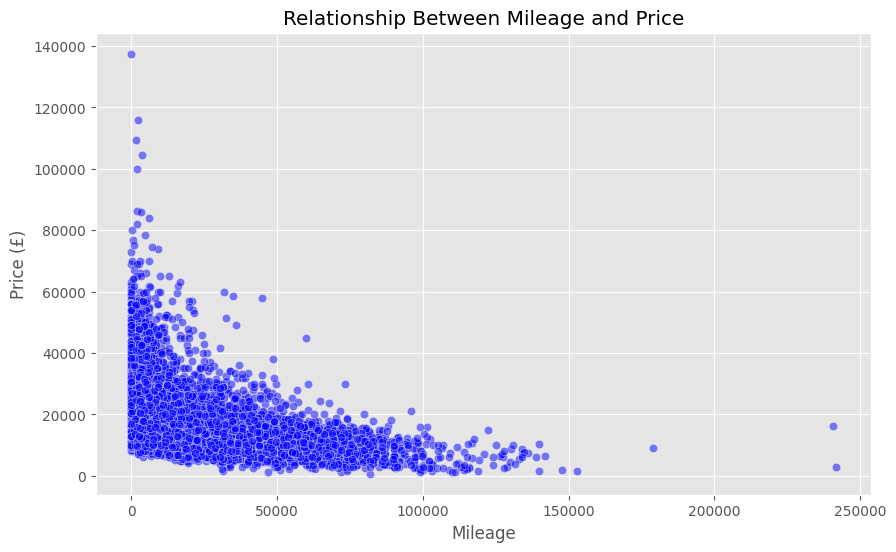

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Settings of shapes
plt.style.use('ggplot')

# 1. (Price Distribution across Brands)
plt.figure(figsize=(12, 6))
sns.boxplot(x='brand', y='price', data=df)
plt.title('Price Distribution Across Different Car Brands')
plt.xlabel('Car Brand')
plt.ylabel('Price (£)')
plt.xticks(rotation=45)
plt.show()

print("-" * 50)

# 2. (Mileage vs. Price Relationship) sample
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mileage', y='price', data=df.sample(10000, random_state=42), alpha=0.5, color='blue')
plt.title('Relationship Between Mileage and Price')
plt.xlabel('Mileage')
plt.ylabel('Price (£)')
plt.show()

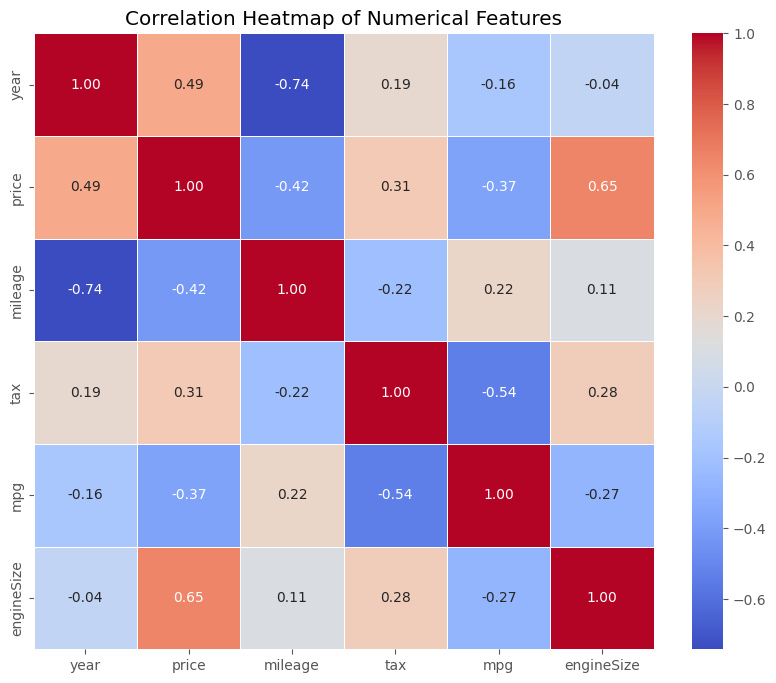

In [7]:
# Correlation Heatmap of Numerical Features
plt.figure(figsize=(10, 8))
numerical_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

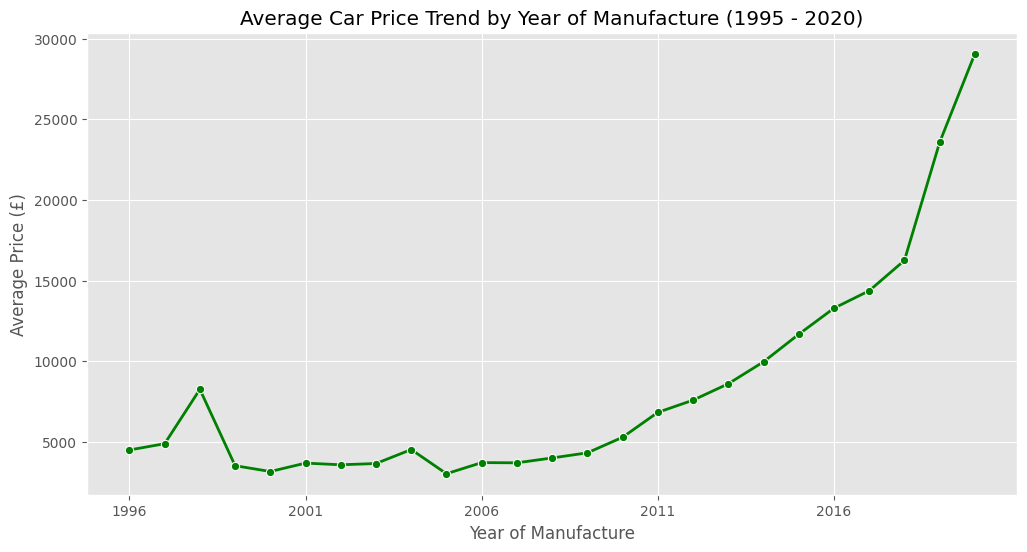

In [8]:
# متوسط سعر كل 5 سنة من اول سنة 1995 علشان مفيش غير عربية واحدة قبل كده
plt.figure(figsize=(12, 6))
df_trend = df[df['year'] >= 1995]
avg_price_year = df_trend.groupby('year')['price'].mean().reset_index()
sns.lineplot(x='year', y='price', data=avg_price_year, marker='o', color='green', linewidth=2)

plt.title('Average Car Price Trend by Year of Manufacture (1995 - 2020)')
plt.xlabel('Year of Manufacture')
plt.ylabel('Average Price (£)')

# كل 5 سنين
min_year = int(min(avg_price_year['year']))
max_year = int(max(avg_price_year['year']))

plt.xticks(np.arange(min_year, max_year + 1, 5)) 

plt.show()

C:\Users\Omar Lashin\AppData\Local\Temp\ipykernel_14532\3674131619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='transmission', y='price', data=df, palette='Set2', errorbar=None)


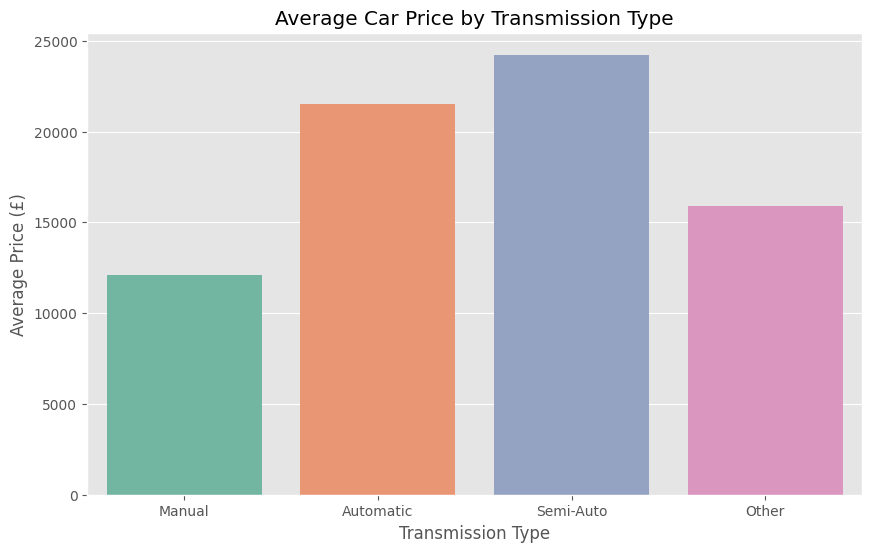

In [9]:
# متوسط السعر حسب نوع الفتيس
plt.figure(figsize=(10, 6))
sns.barplot(x='transmission', y='price', data=df, palette='Set2', errorbar=None)
plt.title('Average Car Price by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Average Price (£)')
plt.show()

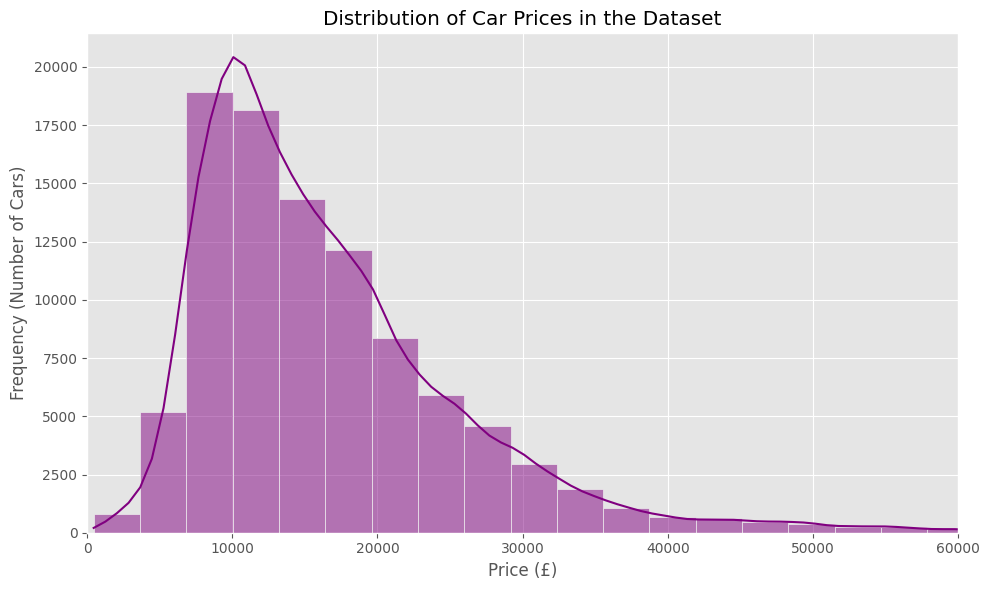

In [10]:
# price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='purple')

plt.title('Distribution of Car Prices in the Dataset')
plt.xlabel('Price (£)')
plt.ylabel('Frequency (Number of Cars)')

plt.xlim(0, 60000) 

plt.tight_layout()
plt.show()

--> Make One-Hot Encoding in Cols (transmission - fuelType - brand - model)

In [4]:
categorical_columns = ['brand', 'model', 'transmission', 'fuelType']
print(f"Table Before Encoding: {df.shape[0]} rows, {df.shape[1]} columns")

Table Before Encoding: 97397 rows, 10 columns


In [5]:
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
print("-" * 50)

--------------------------------------------------


In [13]:
print(f'table After Encoding: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns')
display(df_encoded.head())

table After Encoding: 97397 rows, 212 columns


,year,price,mileage,tax,mpg,engineSize,brand_BMW,brand_Ford,brand_Hyundai,brand_Mercedes,...,model_180,model_200,model_220,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12500,15735,150,55.4,1.4,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,2016,16500,36203,20,64.2,2.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2016,11000,29946,30,55.4,1.4,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,2017,16800,25952,145,67.3,2.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2019,17300,1998,145,49.6,1.0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


# Model Train and Test

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
print("Model Training")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

Model Training


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
# test
predictions = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"First Result (Random Forest): {r2 * 100:.2f}%")
print(f"Model Accuracy : {r2 * 100:.2f}%")
print(f"Mean Absolute Error: £{mae:.2f}")

First Result (Random Forest): 95.66%
Model Accuracy : 95.66%
Mean Absolute Error: £1162.71


C:\Users\Omar Lashin\AppData\Local\Temp\ipykernel_14532\1564225432.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


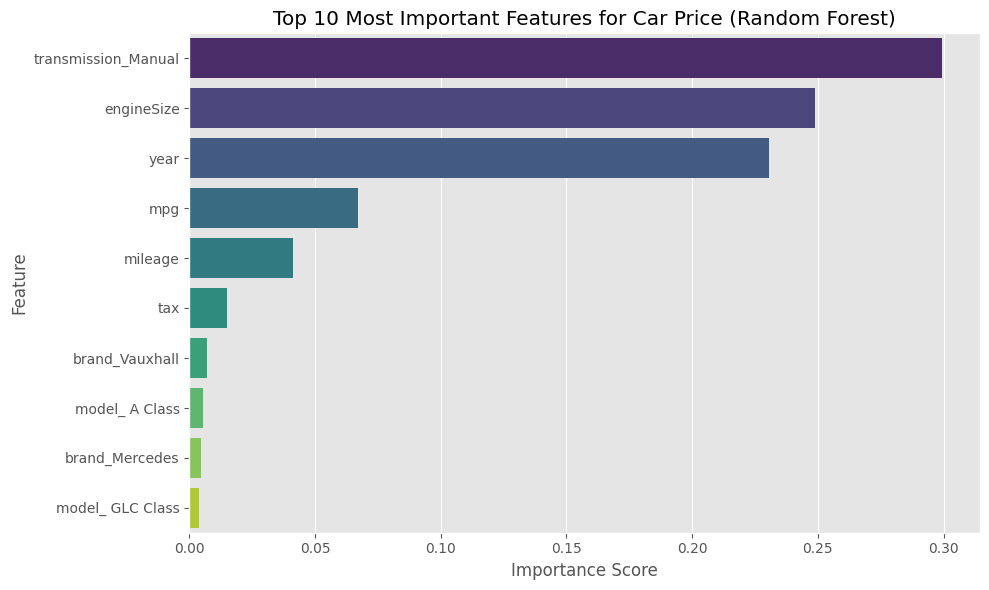

In [18]:
# Feature Importance
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Most Important Features for Car Price (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# New Model For Comparing

In [11]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [12]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

In [13]:
# Train
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [22]:
xgb_predictions = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f"Second Result (XGBoost):")
print(f"Model Accuracy : {xgb_r2 * 100:.2f}%")
print(f"Mean Absolute Error: £±{xgb_mae:.2f}")

Second Result (XGBoost):
Model Accuracy : 93.72%
Mean Absolute Error: £±1590.42


## Phase 2 — Hyperparameter Tuning (Deliverable 3)

In this phase we will:
- Add **RMSE** to the evaluation metrics (along with **MAE** and **R²**)
- Tune **Random Forest** using a classic search strategy (RandomizedSearchCV / small GridSearch)
- Tune **XGBoost** using **Bayesian optimization** (Optuna)
- Compare baseline vs tuned models on the same test split

Notes:
- We will tune using **CV** or a **train/valid** split to avoid leaking information from the test set.
- These searches can take time. You can adjust `N_ITER` / `N_TRIALS` to fit your laptop.

In [16]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split

RANDOM_STATE = 42

# ---- Metrics helper ----
def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {"rmse": rmse, "mae": mae, "r2": r2}

# ---- Baseline metrics (from your already-trained models above) ----
baseline_rf = regression_metrics(y_test, rf_model.predict(X_test))
baseline_xgb = regression_metrics(y_test, xgb_model.predict(X_test))

print("Baseline Random Forest:", baseline_rf)
print("Baseline XGBoost:", baseline_xgb)

Baseline Random Forest: {'rmse': 2060.523794853174, 'mae': 1162.7078965714768, 'r2': 0.9566438399931111}
Baseline XGBoost: {'rmse': 2480.3034088594886, 'mae': 1590.421142578125, 'r2': 0.9371789693832397}


### Strategy A — Classic search (RandomizedSearchCV) for Random Forest

Why this strategy:
- Random Forest has many hyperparameters; a full grid can explode combinatorially.
- Randomized search gives strong results quickly with a fixed budget (`N_ITER`).

What we optimize:
- Primary: **RMSE** (lower is better)
- We’ll still report MAE and R² for interpretation.

In [22]:
from sklearn.ensemble import RandomForestRegressor

# Search budget (increase for better results)
N_ITER = 15
CV_SPLITS = 3

rf_param_distributions = {
    "n_estimators": [150, 250, 400],  # smaller
    "max_depth": [10, 20, None],      # keep some flexibility
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.8],
}

rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_distributions,
    n_iter=10,  # reduce from 15
    scoring="neg_mean_absolute_error",  # align with project
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

rf_search.fit(X_train, y_train)

print("Best RF params:")
print(rf_search.best_params_)
print("Best CV MAE:", -rf_search.best_score_)

rf_tuned = rf_search.best_estimator_
rf_tuned_metrics = regression_metrics(y_test, rf_tuned.predict(X_test))
print("Tuned Random Forest (test):", rf_tuned_metrics)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF params:
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV MAE: 1167.1631880295474
Tuned Random Forest (test): {'rmse': 1999.0253675823296, 'mae': 1139.4069535052454, 'r2': 0.9591932363266866}


### Strategy B — Bayesian optimization (Optuna) for XGBoost

Why Bayesian optimization:
- It **learns** which hyperparameter regions work well and focuses search there.
- Often reaches good performance in fewer trials than grid search.

We’ll tune using a **train/valid** split (from the training data only) and keep the test set untouched for final reporting.

In [15]:
# Optional dependency: Optuna (Bayesian optimization)
# If this cell errors, install with: pip install optuna
try:
    import optuna
    OPTUNA_AVAILABLE = True
    print("Optuna is available:", optuna.__version__)
except Exception as e:
    OPTUNA_AVAILABLE = False
    print("Optuna is NOT available. Error:", e)

Optuna is available: 4.8.0


f:\Omar Study\term8\Software for AI Enabeled Systems\car-rental-ai-app-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
from xgboost import XGBRegressor

# Split training set -> train/valid (ONLY for tuning)
X_train_sub, X_valid, y_train_sub, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE
 )

N_TRIALS = 25  # increase for stronger Bayesian search

def optuna_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 20.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": RANDOM_STATE,
        "tree_method": "hist",
        "n_jobs": -1,
        "eval_metric": "rmse",
        "verbosity": 0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train_sub, y_train_sub)
    preds = model.predict(X_valid)
    rmse = regression_metrics(y_valid, preds)["rmse"]
    return rmse

if OPTUNA_AVAILABLE:
    study = optuna.create_study(direction="minimize")
    study.optimize(optuna_objective, n_trials=N_TRIALS)
    print("Best Optuna RMSE (valid):", study.best_value)
    print("Best params:")
    print(study.best_params)

    tuned_xgb = XGBRegressor(
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
        eval_metric="rmse",
        verbosity=0,
        **study.best_params,
    )
    tuned_xgb.fit(X_train, y_train)
    xgb_tuned_metrics = regression_metrics(y_test, tuned_xgb.predict(X_test))
    print("Tuned XGBoost (test):", xgb_tuned_metrics)
else:
    print("Skip Bayesian tuning because Optuna is not installed.")

[I 2026-04-28 21:40:11,731] A new study created in memory with name: no-name-a0bdd8fa-1455-4735-99f1-7989e8714917
[I 2026-04-28 21:40:29,413] Trial 0 finished with value: 1795.656147484813 and parameters: {'n_estimators': 551, 'learning_rate': 0.028779034910755837, 'max_depth': 10, 'min_child_weight': 1.060947816244365, 'subsample': 0.6206231389695412, 'colsample_bytree': 0.6251329013394356, 'gamma': 1.0858304579429068, 'reg_alpha': 0.006115716829042351, 'reg_lambda': 0.08091366062321816}. Best is trial 0 with value: 1795.656147484813.
[I 2026-04-28 21:40:50,568] Trial 1 finished with value: 1887.2361404975265 and parameters: {'n_estimators': 1230, 'learning_rate': 0.2492829380624199, 'max_depth': 8, 'min_child_weight': 1.313914127448297, 'subsample': 0.6747158212786607, 'colsample_bytree': 0.6378335276690278, 'gamma': 3.6378943790736273, 'reg_alpha': 0.00037891251436820734, 'reg_lambda': 0.3410087292240692}. Best is trial 0 with value: 1795.656147484813.
[I 2026-04-28 21:41:13,939] Tr

Best Optuna RMSE (valid): 1729.0473533133788
Best params:
{'n_estimators': 1351, 'learning_rate': 0.03811913399840194, 'max_depth': 12, 'min_child_weight': 13.898246040882487, 'subsample': 0.9456557255479215, 'colsample_bytree': 0.7863901841281051, 'gamma': 2.2127047114175675, 'reg_alpha': 7.886257335099341e-06, 'reg_lambda': 0.001340819141810469}
Tuned XGBoost (test): {'rmse': 1922.5758112490648, 'mae': 1078.347900390625, 'r2': 0.9622547626495361}


In [23]:
# ---- Summary table (baseline vs tuned) ----
results = []
results.append({"model": "RandomForest (baseline)", **baseline_rf})
results.append({"model": "XGBoost (baseline)", **baseline_xgb})

# rf_tuned_metrics exists after running the RF tuning cell above
if "rf_tuned_metrics" in globals():
    results.append({"model": "RandomForest (tuned)", **rf_tuned_metrics})

# xgb_tuned_metrics exists after running the Optuna cell above
if "xgb_tuned_metrics" in globals():
    results.append({"model": "XGBoost (tuned)", **xgb_tuned_metrics})

results_df = pd.DataFrame(results).sort_values(by="rmse")
display(results_df)

,model,rmse,mae,r2
3,XGBoost (tuned),1922.575811,1078.347900,0.962255
2,RandomForest (tuned),1999.025368,1139.406954,0.959193
0,RandomForest (baseline),2060.523795,1162.707897,0.956644
1,XGBoost (baseline),2480.303409,1590.421143,0.937179


## Phase 3 — Model Finalization + Saving (API-Ready)

In this phase we will save **everything the API needs**:

1. **Model columns** (the exact one-hot encoded column order used during training)
2. **Final model** (the best-performing model we trained/tuned)
3. A `preprocess_input()` function that takes a raw JSON-like dict and produces a correctly aligned feature vector

Why this matters:
- Your models were trained on **one-hot encoded columns** (hundreds of features).
- The API will receive **raw inputs** (brand/model/transmission/fuelType...).
- So we must recreate the same encoding and **reindex** to match training columns exactly.

In [24]:
import os
from pathlib import Path

import joblib
import pandas as pd

# --- Paths for artifacts (what the API will load) ---
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

COLUMNS_PATH = ARTIFACT_DIR / "model_columns.pkl"
FINAL_MODEL_PATH = ARTIFACT_DIR / "final_model.pkl"

# --- Choose the final model (lowest RMSE on test among available models) ---
candidates = []

if "rf_model" in globals():
    candidates.append(("RandomForest (baseline)", rf_model))
if "rf_tuned" in globals():
    candidates.append(("RandomForest (tuned)", rf_tuned))
if "xgb_model" in globals():
    candidates.append(("XGBoost (baseline)", xgb_model))
if "tuned_xgb" in globals():
    candidates.append(("XGBoost (tuned)", tuned_xgb))

if not candidates:
    raise RuntimeError("No trained models found in memory. Run the training cells first.")

# Evaluate candidates on the same test set using RMSE
scored = []
for name, model in candidates:
    preds = model.predict(X_test)
    m = regression_metrics(y_test, preds)
    scored.append({"model": name, **m})

scores_df = pd.DataFrame(scored).sort_values(by="rmse").reset_index(drop=True)
display(scores_df)

best_model_name = scores_df.loc[0, "model"]
best_rmse = scores_df.loc[0, "rmse"]
print(f"Selected final model: {best_model_name} (test RMSE={best_rmse:.2f})")

final_model = dict(candidates)[best_model_name]

# --- Save columns (CRITICAL: exact order must match training) ---
model_columns = list(X_train.columns)
joblib.dump(model_columns, COLUMNS_PATH)
print("Saved model columns to:", COLUMNS_PATH)

# --- Save final model ---
joblib.dump(final_model, FINAL_MODEL_PATH)
print("Saved final model to:", FINAL_MODEL_PATH)

,model,rmse,mae,r2
0,XGBoost (tuned),1922.575811,1078.347900,0.962255
1,RandomForest (tuned),1999.025368,1139.406954,0.959193
2,RandomForest (baseline),2060.523795,1162.707897,0.956644
3,XGBoost (baseline),2480.303409,1590.421143,0.937179


Selected final model: XGBoost (tuned) (test RMSE=1922.58)
Saved model columns to: artifacts\model_columns.pkl
Saved final model to: artifacts\final_model.pkl


In [27]:
def preprocess_input(input_dict: dict, model_columns: list[str]) -> pd.DataFrame:
    """Convert raw API input into a one-hot encoded row aligned to training columns."""
    df_in = pd.DataFrame([input_dict]).copy()

    # Clean strings (avoid issues like leading/trailing spaces, e.g. " A1")
    for col in ["brand", "model", "transmission", "fuelType"]:
        if col in df_in.columns:
            df_in[col] = df_in[col].astype(str).str.strip()

    # One-hot encode categorical values (same approach as training)
    df_in = pd.get_dummies(df_in)

    # Align to training columns (CRITICAL)
    df_in = df_in.reindex(columns=model_columns, fill_value=0)
    return df_in

In [28]:
# --- Test: simulate API input dict -> preprocess -> predict ---
loaded_model = joblib.load(FINAL_MODEL_PATH)
loaded_columns = joblib.load(COLUMNS_PATH)

# Create a realistic sample from the dataset (first row after cleaning)
sample = df.iloc[0].drop("price").to_dict()
print("Sample input (raw):", sample)

processed = preprocess_input(sample, loaded_columns)
print("Processed shape:", processed.shape)
assert list(processed.columns) == loaded_columns, "Column order mismatch!"

prediction = loaded_model.predict(processed)[0]
print("Predicted Price:", float(prediction))

Sample input (raw): {'brand': 'Audi', 'model': ' A1', 'year': 2017, 'transmission': 'Manual', 'mileage': 15735, 'fuelType': 'Petrol', 'tax': 150, 'mpg': 55.4, 'engineSize': 1.4}
Processed shape: (1, 211)
Predicted Price: 12651.494140625
